Fig5C


Aggregating data from 15 directories...


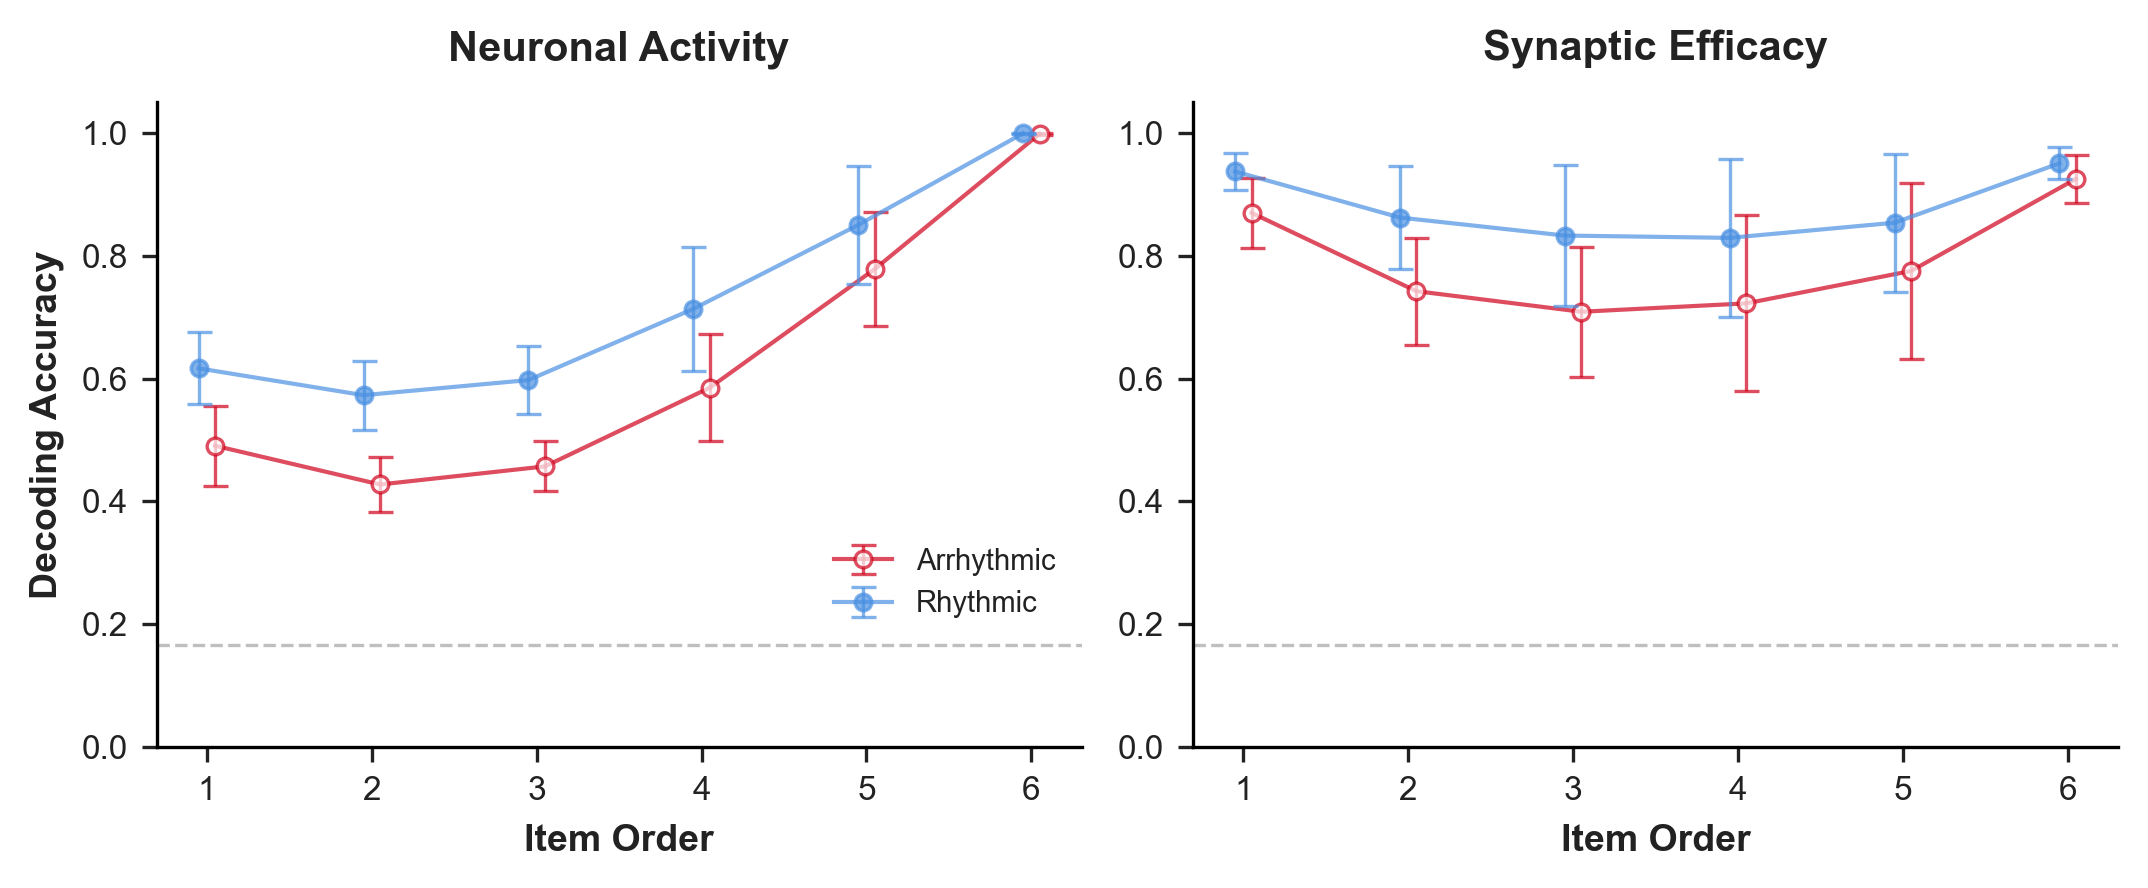

Done. Error bars represent Standard Deviation across all directories.

[Neuronal]
Pos   | Rhythmic             | Arrhythmic          
-------------------------------------------------------
1     | 0.6167 ± 0.0152      | 0.4907 ± 0.0168
2     | 0.5730 ± 0.0144      | 0.4276 ± 0.0116
3     | 0.5976 ± 0.0144      | 0.4570 ± 0.0105
4     | 0.7134 ± 0.0261      | 0.5852 ± 0.0226
5     | 0.8501 ± 0.0246      | 0.7782 ± 0.0240
6     | 0.9992 ± 0.0003      | 0.9984 ± 0.0004

[Synaptic]
Pos   | Rhythmic             | Arrhythmic          
-------------------------------------------------------
1     | 0.9372 ± 0.0078      | 0.8699 ± 0.0148
2     | 0.8622 ± 0.0216      | 0.7423 ± 0.0224
3     | 0.8329 ± 0.0295      | 0.7088 ± 0.0274
4     | 0.8291 ± 0.0332      | 0.7225 ± 0.0370
5     | 0.8537 ± 0.0290      | 0.7752 ± 0.0372
6     | 0.9505 ± 0.0068      | 0.9252 ± 0.0102


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import os

target_dirs = [
    '100-250','100-300','100-350','100-400','100-450','100-500',
    '120-300','120-350','120-400','120-450','120-500',
    '140-350','140-400','140-450','140-500'
]

def set_pub_style():
    plt.style.use('default')
    mpl.rcParams['font.family'] = 'sans-serif'
    mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
    mpl.rcParams['font.size'] = 8
    mpl.rcParams['axes.labelsize'] = 9
    mpl.rcParams['axes.titlesize'] = 10
    mpl.rcParams['xtick.labelsize'] = 8
    mpl.rcParams['ytick.labelsize'] = 8
    mpl.rcParams['legend.fontsize'] = 8
    
    # 
    mpl.rcParams['axes.linewidth'] = 0.8
    mpl.rcParams['lines.linewidth'] = 1.0
    mpl.rcParams['lines.markersize'] = 4
    mpl.rcParams['lines.markeredgewidth'] = 0.8
    
    # 
    mpl.rcParams['axes.spines.top'] = False
    mpl.rcParams['axes.spines.right'] = False
    mpl.rcParams['xtick.direction'] = 'out'
    mpl.rcParams['ytick.direction'] = 'out'
    
    # 
    mpl.rcParams['text.color'] = '#222222'
    mpl.rcParams['axes.labelcolor'] = '#222222'
    mpl.rcParams['xtick.color'] = '#222222'
    mpl.rcParams['ytick.color'] = '#222222'

set_pub_style()


def parse_base_dir(base_dir_name):
    try:
        sd_str, ioi_str = base_dir_name.strip('/').split('-')
        sd = int(sd_str) / 10.0
        ioi = int(ioi_str) / 10.0
        return sd, ioi
    except:
        return None, None

def get_position_windows(ioi, sd, t_start=50):
    windows = {
        1: (int(t_start + 0*ioi), int(t_start + 5*ioi + sd + 100)),
        2: (int(t_start + 1*ioi), int(t_start + 5*ioi + sd + 100)),
        3: (int(t_start + 2*ioi), int(t_start + 5*ioi + sd + 100)),
        4: (int(t_start + 3*ioi), int(t_start + 5*ioi + sd + 100)),
        5: (int(t_start + 4*ioi), int(t_start + 5*ioi + sd + 100)),
        6: (int(t_start + 5*ioi), int(t_start + 5*ioi + sd + 100)),
    }
    return windows

def get_mean_acc_vector(data, key, windows):
    raw = data[key]
    means = []
    for pos in range(1, 7):
        t0, t1 = windows[pos]
        if t1 > raw.shape[0]: t1 = raw.shape[0]
        sliced = raw[t0:t1, pos-1]
        means.append(np.mean(sliced))
    return np.array(means)

collected_data = {
    'rhy_neu': [], 'rhy_syn': [],
    'arr_neu': [], 'arr_syn': []
}

print(f"Aggregating data from {len(target_dirs)} directories...")

for d in target_dirs:
    path_rhy = os.path.join(d, 'results', 'rhy_ch0_decoding_results.npz')
    path_arr = os.path.join(d, 'results', 'arrhy_ch0_decoding_results.npz')
    
    if not (os.path.exists(path_rhy) and os.path.exists(path_arr)):
        print(f"Skipping {d}")
        continue
        
    try:
        data_rhy = np.load(path_rhy)
        data_arr = np.load(path_arr)
        
        sd, ioi = parse_base_dir(d)
        windows = get_position_windows(ioi, sd, t_start=50)
        
        collected_data['rhy_neu'].append(get_mean_acc_vector(data_rhy, 'acc_neuronal', windows))
        collected_data['rhy_syn'].append(get_mean_acc_vector(data_rhy, 'acc_synaptic', windows))
        collected_data['arr_neu'].append(get_mean_acc_vector(data_arr, 'acc_neuronal', windows))
        collected_data['arr_syn'].append(get_mean_acc_vector(data_arr, 'acc_synaptic', windows))
    except Exception as e:
        print(f"Error in {d}: {e}")

stats = {'pos': np.arange(1, 7)}
for key in collected_data:
    matrix = np.array(collected_data[key])
    stats[f'{key}_mean'] = np.mean(matrix, axis=0)
    stats[f'{key}_std']  = np.std(matrix, axis=0)

def plot_academic_comparison_with_error(stats):
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3), dpi=300)

    c_rhy = '#4A90E2'
    c_arr = '#D0021B'

    offset = 0.05
    
    def draw_panel(ax, key_rhy, key_arr, title, ylabel=False):
        x = stats['pos']

        x_rhy = x - offset
        x_arr = x + offset
        
        y_rhy_mean = stats[f'{key_rhy}_mean']
        y_rhy_std  = stats[f'{key_rhy}_std']
        
        y_arr_mean = stats[f'{key_arr}_mean']
        y_arr_std  = stats[f'{key_arr}_std']
        
        ax.errorbar(x_arr, y_arr_mean, yerr=y_arr_std, 
                    fmt='-o', color=c_arr, ecolor=c_arr, alpha=0.7,
                    capsize=3, capthick=0.8,elinewidth=0.8,
                    markerfacecolor='white', markeredgecolor=c_arr,
                    label='Arrhythmic', zorder=1)
        
        ax.errorbar(x_rhy, y_rhy_mean, yerr=y_rhy_std, 
                    fmt='-o', color=c_rhy, ecolor=c_rhy, alpha=0.7,
                    capsize=3, capthick=0.8, elinewidth=0.8,
                    markerfacecolor=c_rhy, markeredgecolor=c_rhy,
                    label='Rhythmic', zorder=2)
        
        ax.set_title(title, fontweight='bold', pad=10)
        ax.set_ylim(0, 1.05)
        ax.set_xticks(x)
        ax.set_xlabel('Item Order', fontweight='bold')
        
        if ylabel:
            ax.set_ylabel('Decoding Accuracy', fontweight='bold')
            
        ax.axhline(y=1/6, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)

    draw_panel(axes[0], 'rhy_neu', 'arr_neu', 'Neuronal Activity', ylabel=True)
    
    draw_panel(axes[1], 'rhy_syn', 'arr_syn', 'Synaptic Efficacy', ylabel=False)
    
    axes[0].legend(frameon=False, loc='upper right', bbox_to_anchor=(1, 0.35), fontsize=7)
    
    plt.tight_layout()
    plt.savefig('performance_comparison_with_item_order.pdf', format='pdf', transparent=True)
    plt.show()

if len(collected_data['rhy_neu']) > 0:
    plot_academic_comparison_with_error(stats)
    print("Done. Error bars represent Standard Deviation across all directories.")
else:
    print("No data collected.")


stats = {'pos': np.arange(1, 7)}
for key in collected_data:
    matrix = np.array(collected_data[key])
    n = matrix.shape[0]
    stats[f'{key}_mean'] = np.mean(matrix, axis=0)
    stats[f'{key}_std']  = np.std(matrix, axis=0)
    stats[f'{key}_sem']  = np.std(matrix, axis=0) / np.sqrt(n)

for label, suffix in [('Neuronal', 'neu'), ('Synaptic', 'syn')]:
    print(f"\n[{label}]")
    print(f"{'Pos':<5} | {'Rhythmic':<20} | {'Arrhythmic':<20}")
    print("-" * 55)
    for i in range(6):
        m_r = stats[f'rhy_{suffix}_mean'][i]
        s_r = stats[f'rhy_{suffix}_sem'][i]
        m_a = stats[f'arr_{suffix}_mean'][i]
        s_a = stats[f'arr_{suffix}_sem'][i]
        print(f"{i+1:<5} | {m_r:.4f} ± {s_r:.4f}      | {m_a:.4f} ± {s_a:.4f}")

Fig5D


Processing 15 directories...

Data collected (count per pos):
Pos 1: Rhy=8, Arr=8
Pos 2: Rhy=13, Arr=13
Pos 3: Rhy=14, Arr=14
Pos 4: Rhy=14, Arr=14
Pos 5: Rhy=14, Arr=14
Pos 6: Rhy=12, Arr=12
Pos   | Rhythmic                  | Arrhythmic               
-----------------------------------------------------------------
1     | 814.0447 ± 61.6651         | 524.6112 ± 52.2297
2     | 382.4892 ± 59.1988         | 136.9827 ± 18.8955
3     | 276.9155 ± 54.7683         | 151.6440 ± 38.4229
4     | 257.9947 ± 65.6658         | 153.7992 ± 44.6225
5     | 272.0846 ± 68.5328         | 203.4549 ± 57.4027
6     | 590.8226 ± 62.1052         | 544.4332 ± 52.7541


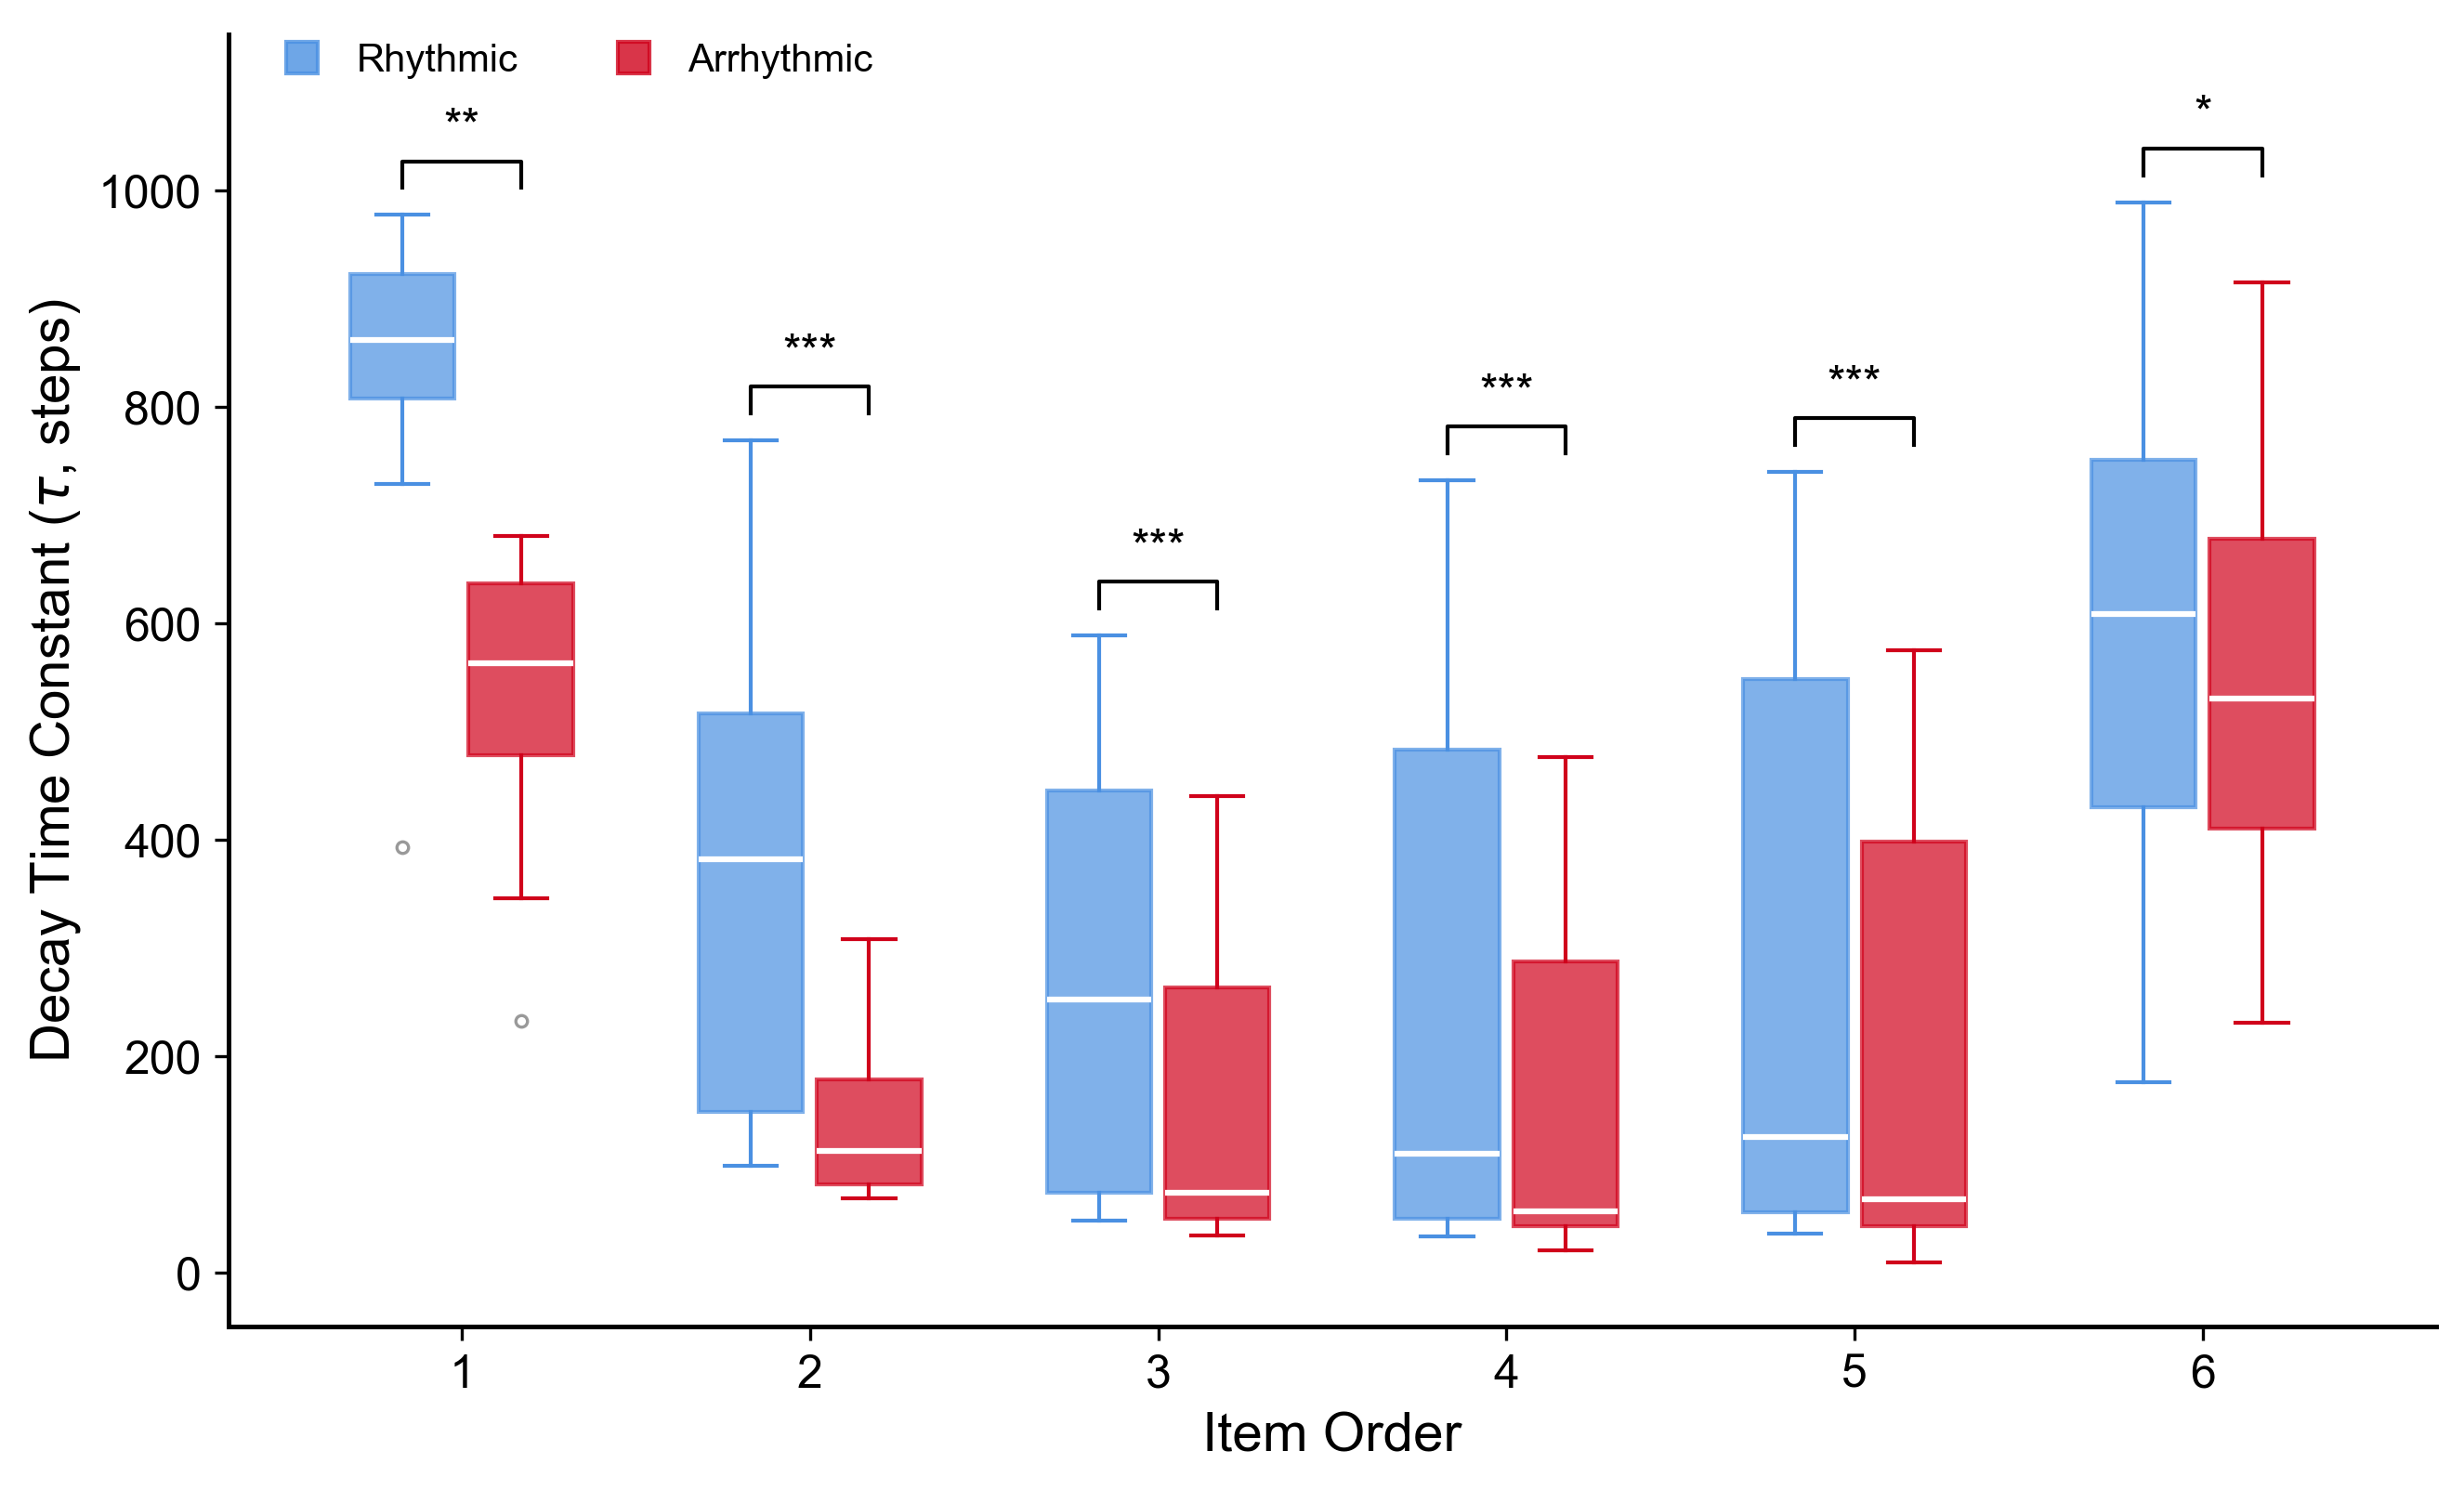

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import os
import json
from scipy.optimize import curve_fit
from scipy import stats

def set_pub_style():
    plt.style.use('default')
    mpl.rcParams['font.family'] = 'sans-serif'
    mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
    mpl.rcParams['font.size'] = 12
    mpl.rcParams['axes.labelsize'] = 14
    mpl.rcParams['axes.titlesize'] = 14
    mpl.rcParams['legend.fontsize'] = 10
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['axes.linewidth'] = 1.2
    mpl.rcParams['lines.linewidth'] = 1.5
    mpl.rcParams['axes.spines.top'] = False
    mpl.rcParams['axes.spines.right'] = False
    mpl.rcParams['xtick.direction'] = 'out'
    mpl.rcParams['ytick.direction'] = 'out'
    mpl.rcParams['boxplot.flierprops.markeredgecolor'] = 'gray'
    mpl.rcParams['boxplot.flierprops.markersize'] = 3

set_pub_style()

COLOR_RHY = '#4A90E2'
COLOR_ARR = '#D0021B'

def exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C

def fit_single_trace(y, t_rel):
    if len(y) < 3:
        return np.nan

    A0 = max(0, float(y[0] - y[-1]))
    C0 = float(y[-1])
    tau0 = max(1.0, (t_rel[-1] - t_rel[0]) / 3.0)
    bounds = ([0.0, 1e-6, 0.0], [np.inf, np.inf, 1.0])
    
    try:
        popt, _ = curve_fit(exp_decay, t_rel, y, p0=[A0, tau0, C0], 
                            bounds=bounds, maxfev=5000)
        tau = popt[1]
        
        if tau > 1000 or tau < 0.1: 
            return np.nan
        return tau
    except:
        return np.nan


def collect_decay_constants(base_dirs, root_path='../'):
    results = {
        'rhy': [[] for _ in range(6)],
        'arr': [[] for _ in range(6)]
    }
    
    print(f"Processing {len(base_dirs)} directories...")
    
    for dir_name in base_dirs:
        full_path = os.path.join(root_path, dir_name)

        sd_str, ioi_str = dir_name.split('-')
        sd = int(int(sd_str)/10)  
        ioi = int(int(ioi_str)/10) 


        meta_path = os.path.join(full_path, 'metadata_seed42_n400.json')
        if not os.path.exists(meta_path):
            print(f"Metadata not found in {dir_name}")
            continue
            
        with open(meta_path, 'r') as f:
            meta = json.load(f)
            test_onsets = meta.get('rhy_ch0_test_onsets', [[0]*6])[0]
            test_onsets_steps = test_onsets 

        res_rhy_path = os.path.join(full_path, 'results', 'rhy_ch0_decoding_results.npz')
        res_arr_path = os.path.join(full_path, 'results', 'arrhy_ch0_decoding_results.npz')

        d_rhy = np.load(res_rhy_path)['acc_synaptic']
        d_arr = np.load(res_arr_path)['acc_synaptic']

        sample_phase_start = 50
        delay_phase_start = 50 + 5 * ioi + sd
        test_phase_base = delay_phase_start + 100 
        
        for k in range(6):
            if k < 5:
                w_start = sample_phase_start + (k + 1) * ioi
            else:
                w_start = delay_phase_start
            
            if k < len(test_onsets_steps):
                w_end = test_phase_base + test_onsets_steps[k]
            else:
                w_end = test_phase_base
            
            w_start = int(w_start)
            w_end = int(w_end)
            
            if w_end > d_rhy.shape[0]: w_end = d_rhy.shape[0]
            
            if w_end - w_start < 5:
                continue
                
            y_rhy = d_rhy[w_start:w_end, k]
            y_arr = d_arr[w_start:w_end, k]
            t_rel = np.arange(len(y_rhy))
            
            # 4. 
            tau_r = fit_single_trace(y_rhy, t_rel)
            tau_a = fit_single_trace(y_arr, t_rel)

            if not np.isnan(tau_r) and not np.isnan(tau_a):
                results['rhy'][k].append(tau_r)
                results['arr'][k].append(tau_a)
            
    return results


def plot_decay_statistics(results):
    fig, ax = plt.subplots(figsize=(9, 5.5), dpi=300)
    
    positions = np.arange(6)
    width = 0.3

    box_common_props = dict(
        patch_artist=True,
        showfliers=True,
        medianprops=dict(color='white', linewidth=1.5, solid_capstyle='butt'),
        flierprops=dict(marker='o', markerfacecolor='none', markersize=3,
                        markeredgecolor='#555555', markeredgewidth=0.8, alpha=0.6)
    )

    bp_r = ax.boxplot(results['rhy'], positions=positions - width/2 - 0.02, widths=width, 
                      **box_common_props,
                      boxprops=dict(facecolor=COLOR_RHY, color=COLOR_RHY, alpha=0.7, linewidth=1),
                      capprops=dict(color=COLOR_RHY, linewidth=1),
                      whiskerprops=dict(color=COLOR_RHY, linewidth=1))
    
    bp_a = ax.boxplot(results['arr'], positions=positions + width/2 + 0.02, widths=width, 
                      **box_common_props,
                      boxprops=dict(facecolor=COLOR_ARR, color=COLOR_ARR, alpha=0.7, linewidth=1),
                      capprops=dict(color=COLOR_ARR, linewidth=1),
                      whiskerprops=dict(color=COLOR_ARR, linewidth=1))


    y_shift_base = np.max([np.max(np.concatenate(results['rhy'])), np.max(np.concatenate(results['arr']))]) * 0.05
    bracket_h = y_shift_base * 0.5

    for k in range(6):
        r_data = np.array(results['rhy'][k])
        a_data = np.array(results['arr'][k])
        r_data = r_data[~np.isnan(r_data)]
        a_data = a_data[~np.isnan(a_data)]
        
        if len(r_data) > 5 and len(a_data) > 5:
            res = stats.wilcoxon(r_data, a_data, alternative='two-sided')
            p_val = res.pvalue

            if p_val < 0.001: sig = '***'
            elif p_val < 0.01: sig = '**'
            elif p_val < 0.05: sig = '*'
            else: sig = 'ns'

            if sig != 'ns':
                x1 = positions[k] - width/2 - 0.02
                x2 = positions[k] + width/2 + 0.02
                y_max_pair = max(np.max(r_data), np.max(a_data))
                bar_y = y_max_pair + y_shift_base
                text_y = bar_y + y_shift_base * 0.2
                
                ax.plot([x1, x1, x2, x2], [bar_y - bracket_h, bar_y, bar_y, bar_y - bracket_h],
                        lw=1.0, c='k')

                ax.text((x1+x2)/2, text_y, sig, ha='center', va='bottom', 
                        fontsize=12, fontweight='normal', color='k')

    ax.set_xticks(positions)
    ax.set_xticklabels([f'{k+1}' for k in range(6)], fontweight='medium')
    ax.set_ylabel(r'Decay Time Constant ($\tau$, steps)')
    ax.set_xlabel('Item Order', fontweight='medium')

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color=COLOR_RHY, lw=0, marker='s', markersize=8, label='Rhythmic', alpha=0.8),
        Line2D([0], [0], color=COLOR_ARR, lw=0, marker='s', markersize=8, label='Arrhythmic', alpha=0.8)
    ]

    ax.legend(handles=legend_elements, loc='upper left', frameon=False, 
              bbox_to_anchor=(0.0, 1.02), ncol=2, handletextpad=0.4)
    
    ax.set_ylim(bottom=-50, top=ax.get_ylim()[1] * 1.05)

    plt.tight_layout()
    plt.savefig('decay_time_boxplot.svg', format='svg', transparent=True)
    plt.show()


if __name__ == "__main__":
    base_dirs = [
        '100-250','100-300','100-350','100-400','100-450','100-500',
        '120-300','120-350','120-400','120-450','120-500',
        '140-350','140-400','140-450','140-500'
    ]

    root_path = r'./' 
    
    data_results = collect_decay_constants(base_dirs, root_path)
    

    print("\nData collected (count per pos):")
    for k in range(6):
        print(f"Pos {k+1}: Rhy={len(data_results['rhy'][k])}, Arr={len(data_results['arr'][k])}")

    print(f"{'Pos':<5} | {'Rhythmic':<25} | {'Arrhythmic':<25}")
    print("-" * 65)
    for k in range(6):
        r_data = np.array(data_results['rhy'][k])
        a_data = np.array(data_results['arr'][k])
        r_data = r_data[~np.isnan(r_data)]
        a_data = a_data[~np.isnan(a_data)]
        m_r = np.mean(r_data)
        s_r = np.std(r_data) / np.sqrt(len(r_data)) if len(r_data) > 0 else np.nan
        m_a = np.mean(a_data)
        s_a = np.std(a_data) / np.sqrt(len(a_data)) if len(a_data) > 0 else np.nan
        print(f"{k+1:<5} | {m_r:.4f} ± {s_r:.4f}         | {m_a:.4f} ± {s_a:.4f}")

    plot_decay_statistics(data_results)